In [1]:
import os
os.chdir('../..')

In [2]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

from src.datasets import QM9Dataset
from src.features import get_features_xyz, get_raw_xyz_features

2026-02-24 17:11:51.018 | INFO     | utils.file_ops:get_device:36 - Using Apple Silicon (MPS)


In [3]:
qm9_loader = QM9Dataset()
qm9_loader.load()
frames = qm9_loader.run_stress_test(mol_ids=["qm9_1237", "qm9_1244", "qm9_1246", "qm9_1248", "qm9_1474", "qm9_1476", "qm9_1478", "qm9_1486", "qm9_1447", "qm9_1449"])
frames_rotated = qm9_loader.run_stress_test(mol_ids=["qm9_1237", "qm9_1244", "qm9_1246", "qm9_1248", "qm9_1474", "qm9_1476", "qm9_1478", "qm9_1486", "qm9_1447", "qm9_1449"], rotated=True)

2026-02-24 17:11:52.248 | INFO     | src.datasets:load:62 - Loading QM9 from data/QM9/dataset_cleaned.csv...
2026-02-24 17:11:52.257 | INFO     | src.geometry:generate_stress_test:56 - Generating Grassmann Stress Test (Seed=40, Rotated=False)...
2026-02-24 17:11:52.320 | INFO     | src.geometry:generate_stress_test:123 - Generated 200 frames. Failed molecules: 0
2026-02-24 17:11:52.337 | SUCCESS  | src.geometry:generate_stress_test:127 - Saved stress test to data/QM9/stress_test.xyz
2026-02-24 17:11:52.338 | INFO     | src.geometry:generate_stress_test:56 - Generating Grassmann Stress Test (Seed=40, Rotated=True)...
2026-02-24 17:11:52.397 | INFO     | src.geometry:generate_stress_test:123 - Generated 200 frames. Failed molecules: 0
2026-02-24 17:11:52.409 | SUCCESS  | src.geometry:generate_stress_test:127 - Saved stress test to data/QM9/stress_test_rotated.xyz


In [4]:
print(f"Loaded {len(frames)} total frames.")

first_frame = frames[0]

print(first_frame.get_positions())

print(first_frame.info['mol_id'])
print(first_frame.info['smiles'])

Loaded 200 total frames.
[[ 3.42626064  0.71131397  0.47139939]
 [ 1.98127123 -0.02074004  0.93609359]
 [ 0.9169506   0.0343536   0.27163376]
 [ 0.85196767  0.80098272 -0.87969272]
 [-0.11043702 -0.91997299  0.54359994]
 [-1.59471164 -0.51128537  0.30085521]
 [-1.78554544  0.88636873  0.16989694]
 [ 3.07841807  1.73092473  0.36004791]
 [ 4.16009748  0.24609888  0.7399839 ]
 [ 3.42235866  0.38050406 -0.92960427]
 [-0.22478572 -0.56852924  1.76973976]
 [-0.0490445  -1.88874036  0.44259037]
 [-1.65138283 -0.77953416 -0.79063823]
 [-2.44015395 -0.9396567   0.68502233]
 [-1.54014014  1.53360536  1.03333521]
 [-3.11119088  0.93418066  0.7000787 ]
 [-1.82570729  1.42564258 -0.86235116]]
qm9_1478
[H]C([H])([H])OC(=O)C([H])([H])C([H])([H])C([H])([H])[H]


In [5]:
ref_pos = frames[0].get_positions()
pert_pos = frames[1].get_positions()

distances = np.linalg.norm(pert_pos - ref_pos, axis=1)

print(f"Analysis for {frames[0].info['mol_id']}:")
print(f"Max displacement: {distances.max():.4f} Å")
print(f"Min displacement: {distances.min():.4f} Å")
print(f"Average displacement: {distances.mean():.4f} Å (Target was ~0.2)")

Analysis for qm9_1478:
Max displacement: 0.5177 Å
Min displacement: 0.0208 Å
Average displacement: 0.2980 Å (Target was ~0.2)


In [6]:
bond_lengths = []
for i in range(20):
    dist = frames[i].get_distance(0, 1)
    bond_lengths.append(dist)

print(f"Original Bond Length (approx): {bond_lengths[0]:.4f} Å")
print(f"Standard Deviation of bond length: {np.std(bond_lengths):.4f} Å")

Original Bond Length (approx): 1.6852 Å
Standard Deviation of bond length: 0.1966 Å


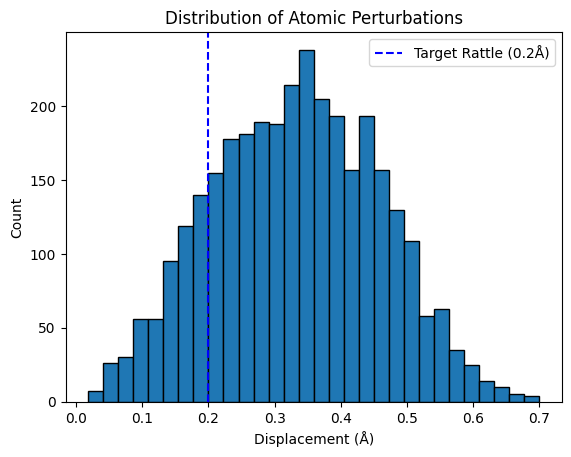

In [7]:
all_displacements = []

for m in range(0, 200, 20):
    ref_pos = frames[m].get_positions()
    for p in range(1, 20):
        pert_pos = frames[m + p].get_positions()
        diff = np.linalg.norm(pert_pos - ref_pos, axis=1)
        all_displacements.extend(diff)

plt.hist(all_displacements, bins=30, edgecolor='black')
plt.axvline(0.2, color='blue', linestyle='--', label='Target Rattle (0.2Å)')
plt.title("Distribution of Atomic Perturbations")
plt.xlabel("Displacement (Å)")
plt.ylabel("Count")
plt.legend()
plt.show()

In [8]:
import ase

part = 'data/QM9/stress_test.xyz'
frames = qm9_loader.run_stress_test()


# Clustering

In [9]:
import polars as pl

def make_clustering(frames, processed=False):
    # --- 1. Generate Features ---
    print("Generating geometric features...")
    if processed:
        X = get_features_xyz(frames)
    else:
        X = get_raw_xyz_features(frames)
        
    print(f"Feature matrix shape: {X.shape}")

    # --- 2. Clustering (K-Means) ---
    unique_mol_ids = list(set([f.info['mol_id'] for f in frames]))
    n_clusters = len(unique_mol_ids)

    print(f"Clustering into {n_clusters} clusters (based on unique mol_ids found)...")
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X)

    # --- 3. Evaluation ---
    true_labels = [f.info['mol_id'] for f in frames]
    smiles_list = [f.info['smiles'] for f in frames]

    # Calculate Score
    ari_score = adjusted_rand_score(true_labels, cluster_labels)
    print(f"Clustering Performance (Adjusted Rand Index): {ari_score:.4f}")

    # --- 4. Cluster Composition Table ---
    # We create a dataframe to easily group and see what went where
    analysis_df = pl.DataFrame({
        "cluster": cluster_labels,
        "true_mol_id": true_labels,
        "smiles": smiles_list
    })

    # Summary: For each cluster, show which molecules it contains and how many
    # If ARI is 1.0, each cluster should only contain 1 unique mol_id
    summary_table = (
        analysis_df.group_by("cluster")
        .agg([
            pl.col("true_mol_id").n_unique().alias("unique_mols"),
            pl.col("true_mol_id").unique().alias("mol_ids_in_cluster"),
            pl.col("smiles").first().alias("representative_smiles"),
            pl.len().alias("total_samples")
        ])
        .sort("cluster")
    )

    print("\nCluster Composition Summary:")
    print(summary_table)

    # --- 5. Visualization (PCA) ---
    print("\nRunning PCA for visualization...")
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    expl_var = pca.explained_variance_ratio_

    # ---------- Styling for report quality ----------
    plt.style.use("seaborn-v0_8-whitegrid")  # clean academic style

    fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

    # Choose color palette depending on number of clusters
    cmap = plt.get_cmap("tab10" if n_clusters <= 10 else "tab20")

    # Scatter plot
    scatter = ax.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=cluster_labels,
        cmap=cmap,
        s=35,
        alpha=0.75,
        edgecolor="black",
        linewidth=0.3
    )

    ax.set_xlabel("PCA Component 1", fontsize=12)
    ax.set_ylabel("PCA Component 2", fontsize=12)

    title_prefix = "Processed (Invariant)" if processed else "Flattened (Raw)"
    ax.set_title(
        f"{title_prefix} XYZ Features — Clustering of Perturbed Geometries\n"
        f"Adjusted Rand Index = {ari_score:.3f}",
        fontsize=14,
        pad=12
    )

    # Cleaner legend
    legend = ax.legend(
        *scatter.legend_elements(num=n_clusters),
        title="Cluster ID",
        loc="best",
        frameon=True
    )
    ax.add_artist(legend)

    # Improve layout
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
    fig.tight_layout()

    # Save high quality figure for report
    plt.savefig(f"report/qm9/figures/grassmann/pca_clustering_{processed}.png", dpi=300, bbox_inches="tight")

    plt.show()
    
    return summary_table

Generating geometric features...
Feature matrix shape: (200, 136)
Clustering into 10 clusters (based on unique mol_ids found)...
Clustering Performance (Adjusted Rand Index): 0.7692

Cluster Composition Summary:
shape: (10, 5)
┌─────────┬─────────────┬─────────────────────────────┬────────────────────────────┬───────────────┐
│ cluster ┆ unique_mols ┆ mol_ids_in_cluster          ┆ representative_smiles      ┆ total_samples │
│ ---     ┆ ---         ┆ ---                         ┆ ---                        ┆ ---           │
│ i32     ┆ u32         ┆ list[str]                   ┆ str                        ┆ u32           │
╞═════════╪═════════════╪═════════════════════════════╪════════════════════════════╪═══════════════╡
│ 0       ┆ 1           ┆ ["qm9_1474"]                ┆ [H]C([H])([H])OC([H])([H]) ┆ 20            │
│         ┆             ┆                             ┆ C(=O…                      ┆               │
│ 1       ┆ 3           ┆ ["qm9_1244", "qm9_1476",    ┆ [H]C([H])(

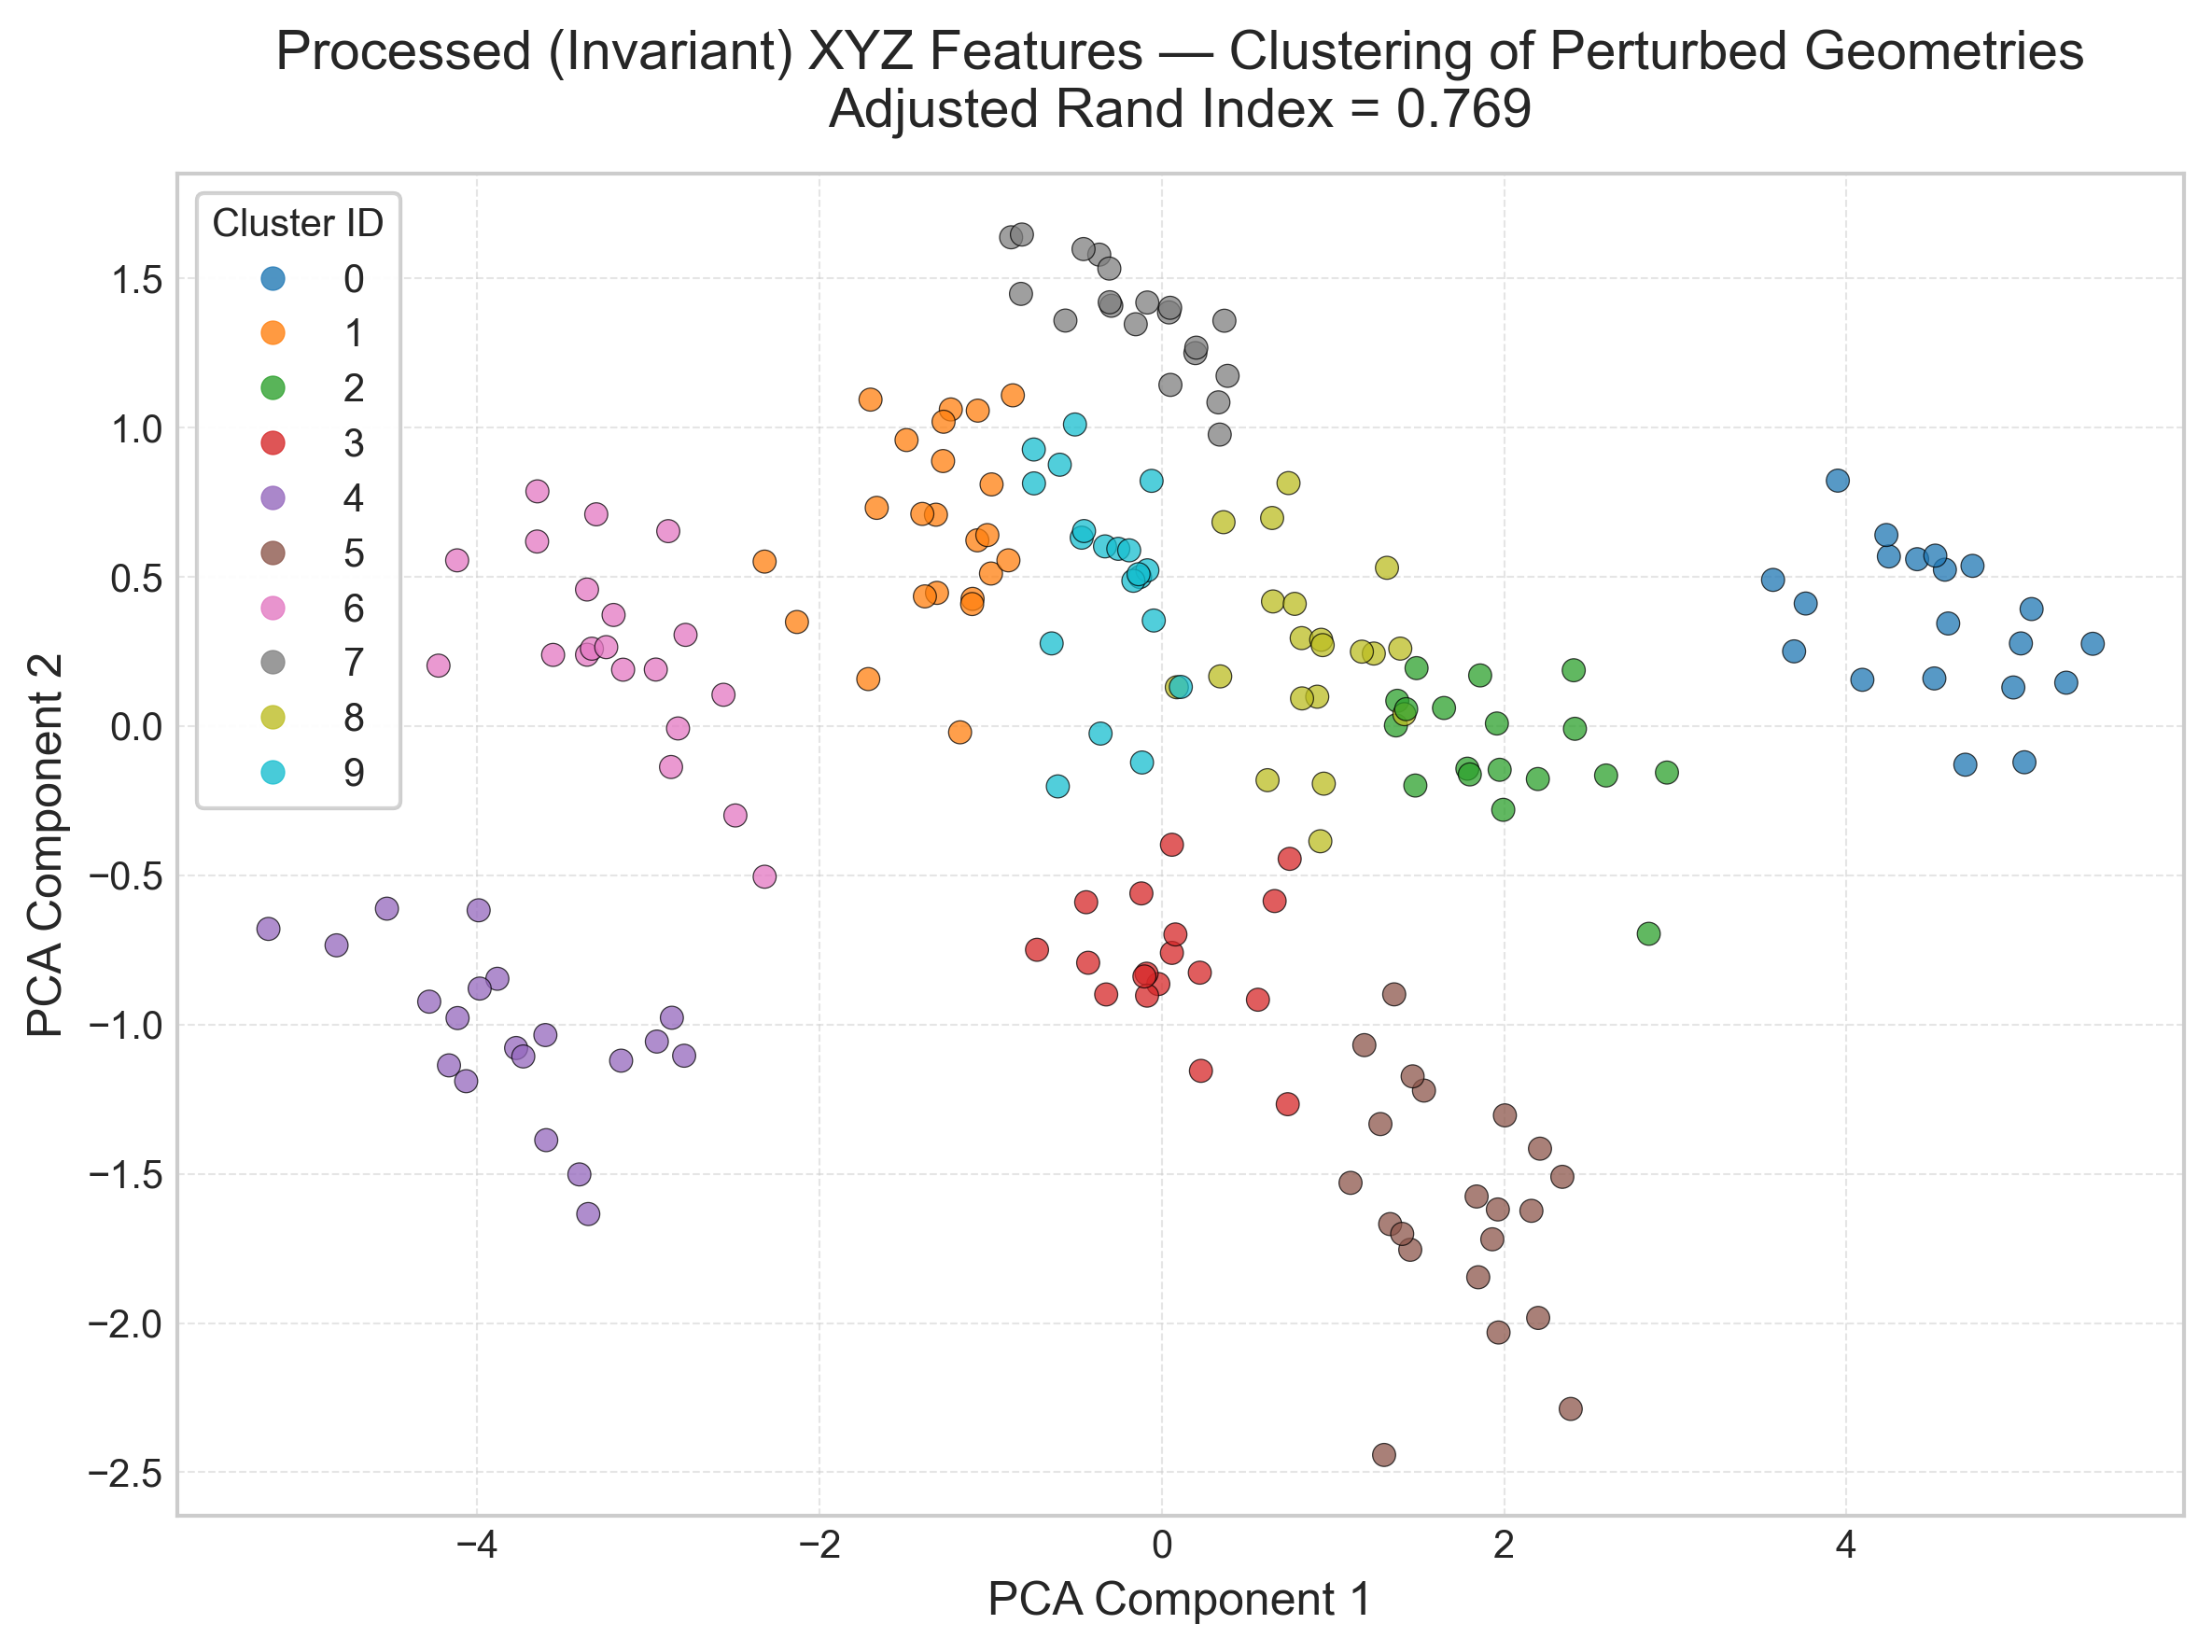

cluster,unique_mols,mol_ids_in_cluster,representative_smiles,total_samples
i32,u32,list[str],str,u32
0,1,"[""qm9_1474""]","""[H]C([H])([H])OC([H])([H])C(=O…",20
1,3,"[""qm9_1244"", ""qm9_1476"", ""qm9_1237""]","""[H]C([H])([H])C(=O)OC([H])([H]…",23
2,2,"[""qm9_1478"", ""qm9_1246""]","""[H]C([H])([H])OC(=O)C([H])([H]…",18
3,2,"[""qm9_1486"", ""qm9_1244""]","""[H]C([H])([H])C([H])([H])OC(=O…",18
4,1,"[""qm9_1447""]","""[H]C(=O)O[C@]([H])(C([H])([H])…",20
5,2,"[""qm9_1486"", ""qm9_1244""]","""[H]C([H])([H])C([H])([H])OC(=O…",21
6,1,"[""qm9_1449""]","""[H]C(=O)C([H])([H])[C@@]([H])(…",20
7,1,"[""qm9_1248""]","""[H]C([H])([H])OC([H])([H])C([H…",20
8,3,"[""qm9_1478"", ""qm9_1246"", ""qm9_1237""]","""[H]C([H])([H])OC(=O)C([H])([H]…",20


In [10]:
make_clustering(frames, processed=True)

Generating geometric features...
flat list 1: [ 3.42626064  0.71131397  0.47139939  1.98127123 -0.02074004  0.93609359
  0.9169506   0.0343536   0.27163376  0.85196767  0.80098272 -0.87969272
 -0.11043702 -0.91997299  0.54359994 -1.59471164 -0.51128537  0.30085521
 -1.78554544  0.88636873  0.16989694  3.07841807  1.73092473  0.36004791
  4.16009748  0.24609888  0.7399839   3.42235866  0.38050406 -0.92960427
 -0.22478572 -0.56852924  1.76973976 -0.0490445  -1.88874036  0.44259037
 -1.65138283 -0.77953416 -0.79063823 -2.44015395 -0.9396567   0.68502233
 -1.54014014  1.53360536  1.03333521 -3.11119088  0.93418066  0.7000787
 -1.82570729  1.42564258 -0.86235116]
flat list 2: [ 3.30146451  0.55901635  0.06783864  2.0023205   0.1246973   0.8752159
  0.9852258   0.07797638  0.43763136  0.77232857  1.04361042 -0.79634895
 -0.14607749 -0.61183129  0.89592563 -1.40508952 -0.17562114 -0.0446555
 -1.72142925  1.09317396  0.25708343  3.27658355  1.52757009  0.15923856
  4.46795676  0.44043774  1.03

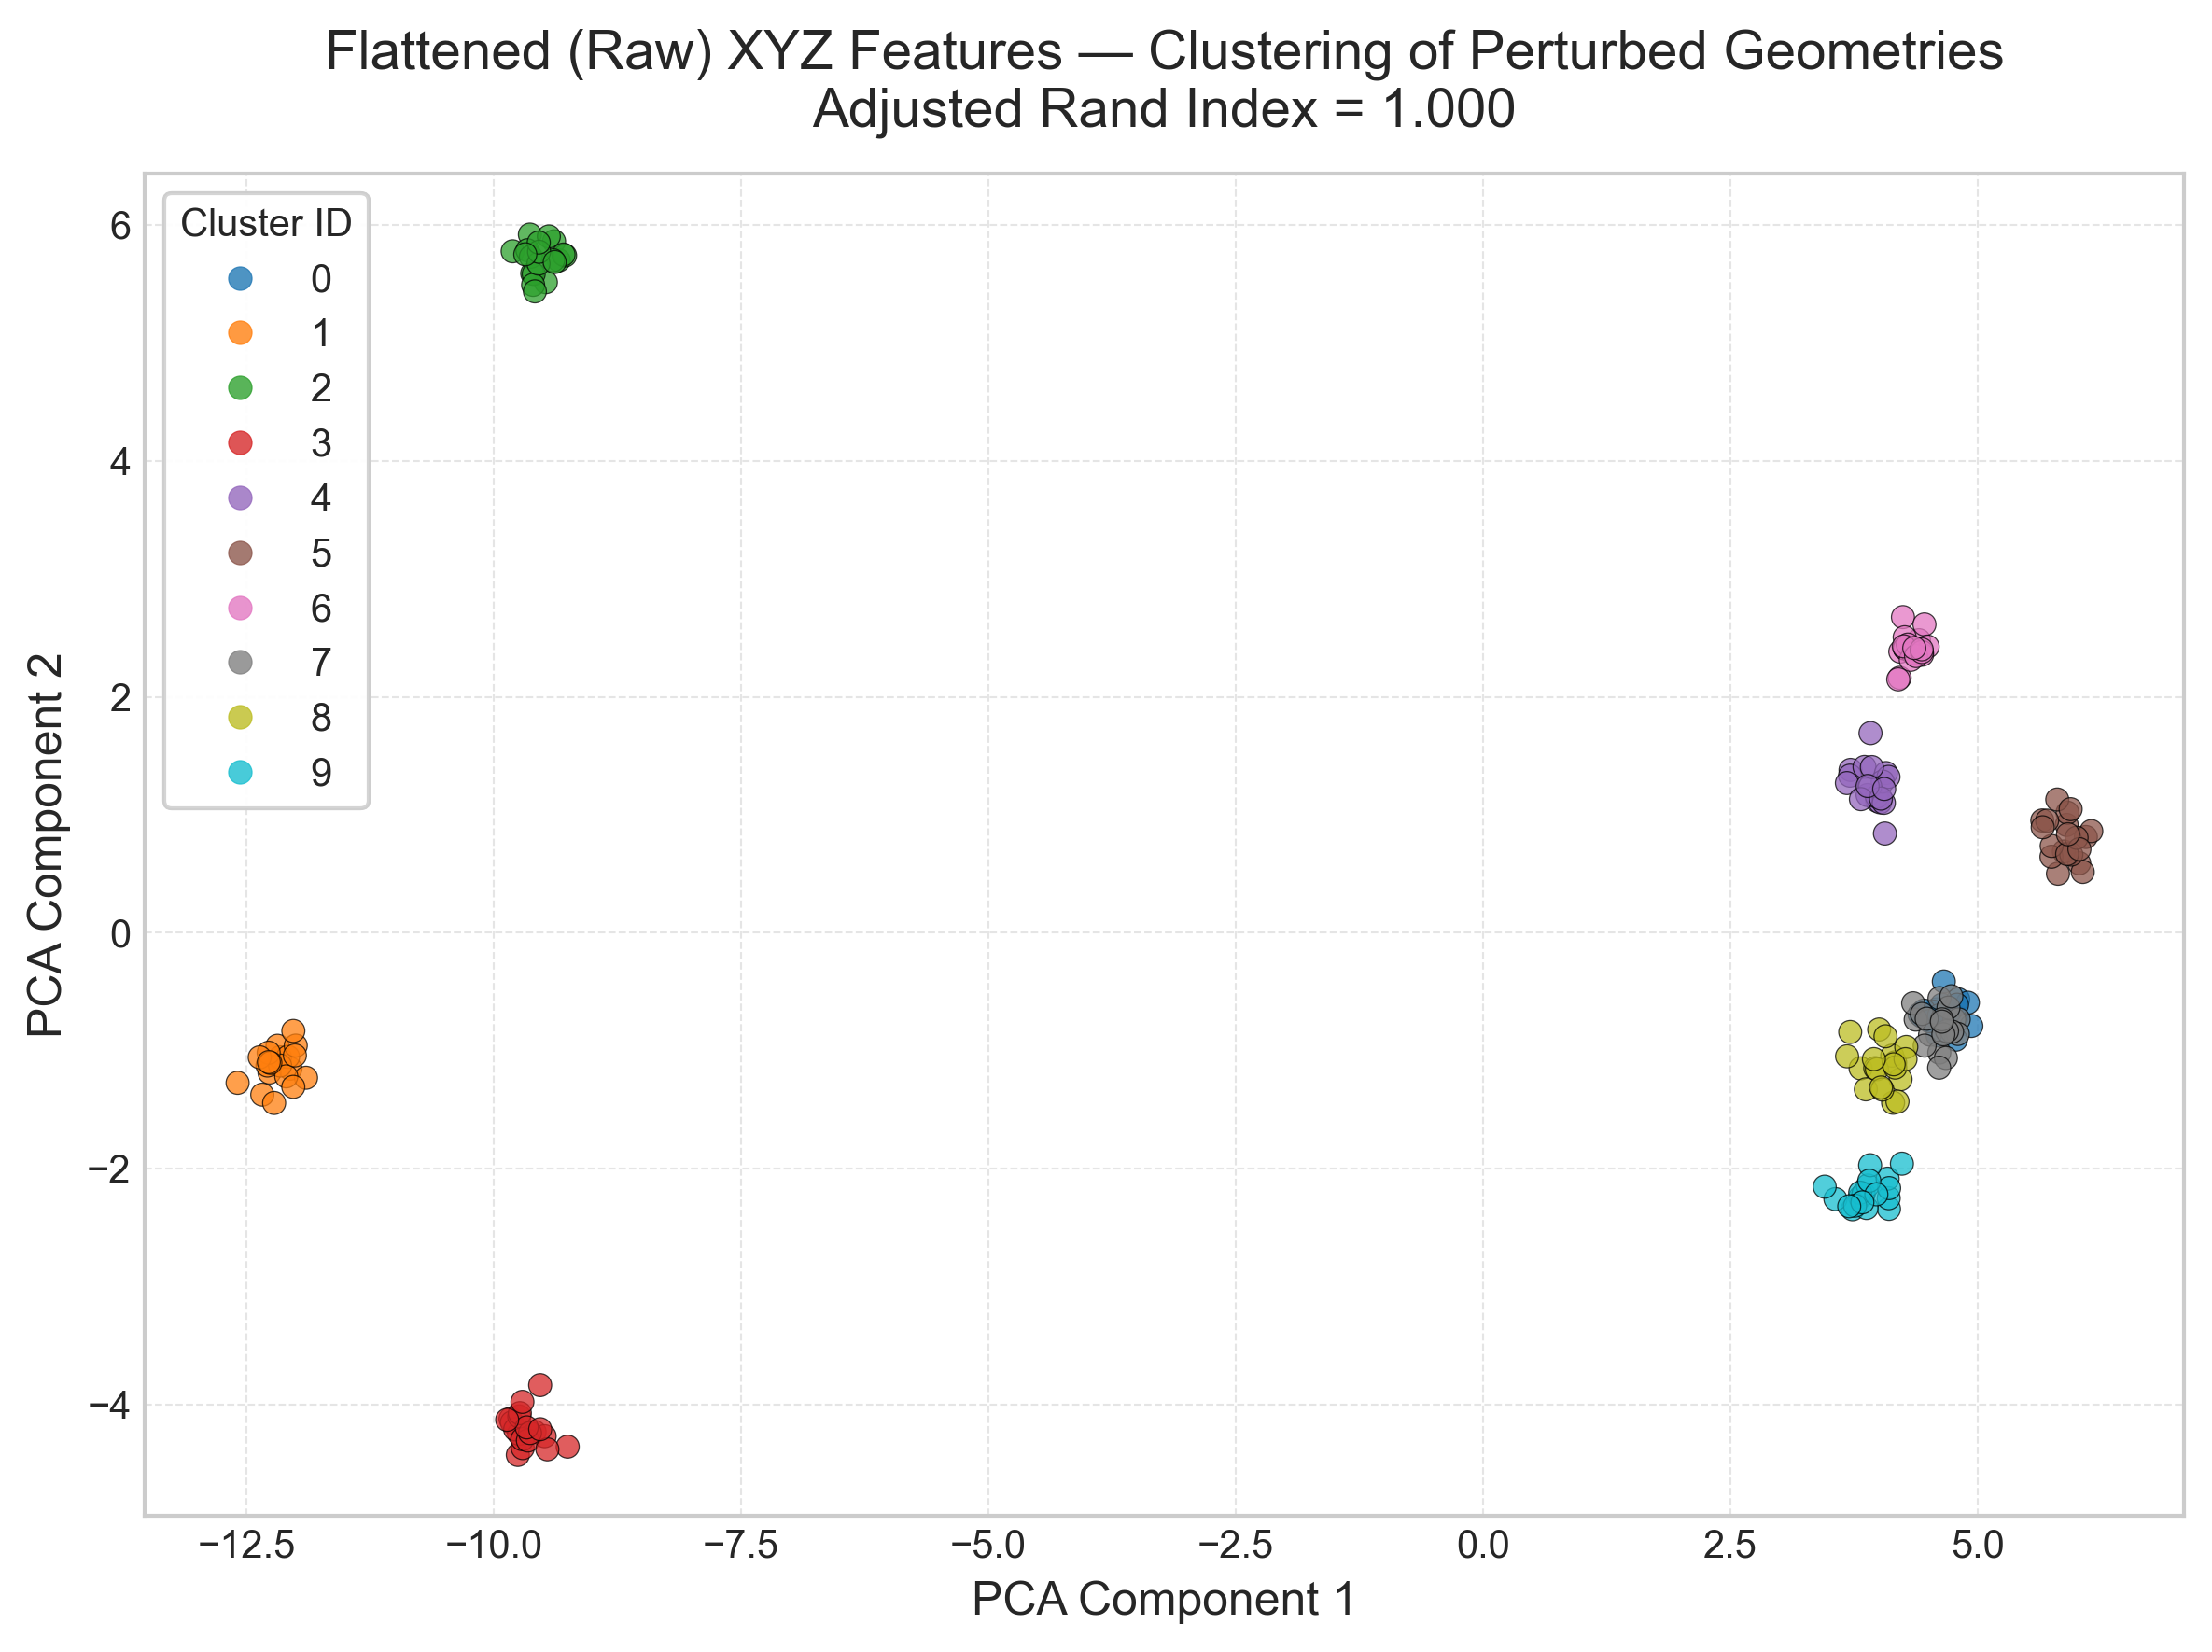

cluster,unique_mols,mol_ids_in_cluster,representative_smiles,total_samples
i32,u32,list[str],str,u32
0,1,"[""qm9_1478""]","""[H]C([H])([H])OC(=O)C([H])([H]…",20
1,1,"[""qm9_1237""]","""[H]OC([H])([H])C([H])([H])C([H…",20
2,1,"[""qm9_1449""]","""[H]C(=O)C([H])([H])[C@@]([H])(…",20
3,1,"[""qm9_1447""]","""[H]C(=O)O[C@]([H])(C([H])([H])…",20
4,1,"[""qm9_1248""]","""[H]C([H])([H])OC([H])([H])C([H…",20
5,1,"[""qm9_1474""]","""[H]C([H])([H])OC([H])([H])C(=O…",20
6,1,"[""qm9_1486""]","""[H]C([H])([H])C([H])([H])OC(=O…",20
7,1,"[""qm9_1246""]","""[H]C([H])([H])C(=O)C([H])([H])…",20
8,1,"[""qm9_1476""]","""[H]OC([H])([H])C(=O)C([H])([H]…",20


In [11]:
make_clustering(frames, processed=False)